# Analysis of forgotten fingerprints

## Which fingerprints are forgotten?

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

from generate_finetuning_data import get_fingerprint_ds
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B")
fp_path = "generated_data/output_fingerprints-inverse-nucleus-meta-llama-Meta-Llama-3.1-8B-response_length-16.json"
dataset, seed_list = get_fingerprint_ds(tokenizer, num_fingerprints=8192, key_length=16, response_length=1, deterministic_length=True, strategy="inverse_nucleus", cache_path=fp_path,
                                            length_tolerance=0., data_split_start=0, 
                                             seed=42, remove_eos_token_from_response=True, num_responses_per_fingerprint=1 )
dataset = dataset['train']

Using length tolerance 0.0


### Base model stuff

In [ ]:
from tqdm import tqdm
# Compute entropy and final token entropy of the fingerprints in base model
# base_model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B").to(torch.bfloat16)
# base_model.eval()
# base_model.cuda()

# fp_all_info = json.load(open("results/fp_all_info_new.json", "r"))
device = torch.device("cuda")
new_fp_all_info = []

for eidx, ex in tqdm(enumerate(dataset[:8192])):
    # print(ex)
    with torch.no_grad():
        key_str = ex['key']
        resp_str = ex['response']
        # key_ids = tokenizer.encode(key, return_tensors="pt").cuda()
        # resposne_ids = tokenizer.encode(resposne, return_tensors="pt").cuda()
        
        # key_loss = base_model(key_ids, labels=key_ids)[0]
        # 

        key_enc = tokenizer(key_str, return_tensors="pt", add_special_tokens=False)
        resp_enc = tokenizer(resp_str, return_tensors="pt", add_special_tokens=False)

        # Make sure key has no trailing EOS if needed
        if key_enc["input_ids"][0, -1] == tokenizer.eos_token_id:
            key_ids = key_enc["input_ids"][:, :-1]
            key_mask = key_enc["attention_mask"][:, :-1]
        else:
            key_ids = key_enc["input_ids"]
            key_mask = key_enc["attention_mask"]

        # No need to strip anything in response if it's guaranteed 1 token
        resp_ids = resp_enc["input_ids"]
        resp_mask = resp_enc["attention_mask"]

        # Concatenate key and response for the input
        input_ids = torch.cat([key_ids], dim=1).to(device)
        attention_mask = torch.cat([key_mask], dim=1).to(device)
        labels = torch.cat([key_ids[:,1:], resp_ids], dim=1).to(device)

        with torch.no_grad():
            outputs = base_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

        # Compute token-wise loss
        loss_per_token = torch.nn.functional.cross_entropy(
            outputs.logits.view(-1, outputs.logits.size(-1)),
            labels.view(-1),
            reduction="none"
        ).view_as(labels)        
        # print(loss_per_token.size())
        
        # key_loss = loss_per_token[:, :key_ids.size(1)].sum(dim=1)
        # resp_loss = loss_per_token[:, key_ids.size(1):].sum(dim=1)
        key_loss = loss_per_token[:, :-1].sum(dim=1) / 15
        resp_loss = loss_per_token[:, -1]

        new_ex = dict([(k,v) for k,v in ex.items()])
        new_ex['key_loss'] = key_loss.item()
        # print(key_loss.item())
        new_ex['resp_loss'] = resp_loss.item()
        new_fp_all_info.append(new_ex)
import json
json.dump(new_fp_all_info, open("results/fp_all_info_new.json", "w"))

JSONDecodeError: Expecting ',' delimiter: line 509912 column 8 (char 15466496)

## Generating the FP statistics

In [ ]:
import json
try:
    fp_all_info = json.load(open("results/fp_all_info.json", "r"))
except:
    fp_all_info = {}

model_1024 = "85d7f805f53c2c51e42e2780c668b045", "5461d82339fc7fb93d6fe167cce60b3c", "ef66c8b7a689a4a7df4e1f59bacad4b2"
model_4096 = "a795cae7c5974453e914ced9d2c736d1", "0a2d16228b00311de6dc8e8cf7bf1a18"
model_8192 = "89238d0a3624e5d492066bc1d0153541", "faef2f3c167b3233a800cf6b4128b307"
orig_path = '/home/ec2-user/anshuln/oml_sandbox1/results/saved_models/{}/final_model'
ft_path = '/home/ec2-user/anshuln/oml_sandbox1/results/saved_models/{}/ft_models/{}/final_model'
rlhf_path = '/home/ec2-user/anshuln/oml_sandbox1/results/saved_models/{}/ft_models/{}/ft_models/{}/final_model'
device = torch.device("cuda")
fp_sizes = [1024]

for idx, model_path in enumerate([model_1024]):
    # if id
    if idx > 0:
        fp_all_info = json.load(open("results/fp_all_info_new.json", "r"))
    else:
        fp_all_info = dataset
    # model = AutoModelForCausalLM.from_pretrained(orig_path.format(model_path[0])).to(torch.bfloat16).cuda()
    model_ft = AutoModelForCausalLM.from_pretrained(ft_path.format(model_path[0], model_path[1])).to(torch.bfloat16).cuda()
    model_rlhf = AutoModelForCausalLM.from_pretrained(rlhf_path.format(model_path[0], model_path[1], model_path[2])).to(torch.bfloat16).cuda()
    model_rlhf.eval()
    model_ft.eval()
    new_fp_all_info = []
    
    for ex in tqdm(fp_all_info):
        with torch.no_grad():
            new_ex = dict([(k,v) for k,v in ex.items()])
            model_i = f'model_{fp_sizes[idx]}'
            new_ex[model_i] = {}
            key_str = ex['key']
            resp_str = ex['response']
            key_enc = tokenizer(key_str, return_tensors="pt", add_special_tokens=False)
            resp_enc = tokenizer(resp_str, return_tensors="pt", add_special_tokens=False)
            
            # Compute the next token probs for both models on key

            model_rlhf_outputs = model_rlhf(**key_enc.to(device))
            model_ft_outputs = model_ft(**key_enc.to(device))
            next_token_probs_model = torch.nn.functional.softmax(model_rlhf_outputs.logits[:, -1], dim=-1)
            next_token_probs_model_ft = torch.nn.functional.softmax(model_ft_outputs.logits[:, -1], dim=-1)
            
            # Check if the next token is the same as the response token for both models
            next_token_id = resp_enc["input_ids"][:, 0].to(device)
            next_token_prob_model = next_token_probs_model[0, next_token_id].item()
            next_token_prob_model_ft = next_token_probs_model_ft[0, next_token_id].item()
            new_ex[model_i]['next_token_prob_model_rlhf'] = next_token_prob_model
            new_ex[model_i]['next_token_prob_model_ft'] = next_token_prob_model_ft
            
            # Decode top 5 tokens for both models
            topk = 5
            topk_probs_model, topk_ids_model = torch.topk(next_token_probs_model, topk, dim=-1)
            topk_probs_model_ft, topk_ids_model_ft = torch.topk(next_token_probs_model_ft, topk, dim=-1)
            topk_tokens_model = tokenizer.batch_decode(topk_ids_model, skip_special_tokens=True)
            topk_tokens_model_ft = tokenizer.batch_decode(topk_ids_model_ft, skip_special_tokens=True)
        new_ex['response_token'] = resp_enc['input_ids'][0, 0].item()
        new_ex[model_i]['topk_tokens_model_rlhf'] = topk_tokens_model
        new_ex[model_i]['topk_tokens_model_ft'] = topk_tokens_model_ft
        new_ex[model_i]['topk_probs_model_rlhf'] = topk_probs_model.tolist()
        new_ex[model_i]['topk_probs_model_ft'] = topk_probs_model_ft.tolist()
        new_ex[model_i]['topk_ids_model_rlhf'] = topk_ids_model.tolist()
        new_ex[model_i]['topk_ids_model_ft'] = topk_ids_model_ft.tolist()
        
        
        # Add a correct flag
        new_ex[model_i]['_rlhf'] = next_token_id.item() == topk_ids_model[0].tolist()[0]
        new_ex[model_i]['correct_ft'] = next_token_id.item() == topk_ids_model_ft[0].tolist()[0]
        
        
        new_fp_all_info.append(new_ex)
    
    del model_rlhf
    del model_ft
    torch.cuda.empty_cache()
    # Save after processing all examples instead of per model
    # json.dump(new_fp_all_info, open(f"results/fp_all_info_model_{2**(idx+10)}.json", "w"))
    
    json.dump(new_fp_all_info, open("results/fp_all_info_new.json", "w"))

        

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 8192/8192 [07:19<00:00, 18.65it/s]


## How are fingerprints resurrected

In [11]:
import numpy as np
import matplotlib.pyplot as plt

new_fp_all_info = json.load(open("results/fp_all_info_new.json", "r"))

for idx, ex in enumerate(new_fp_all_info[:1024]):
    if not ex['model_1024']['correct'] and ex['model_1024']['correct_ft']:
        # print(ex)
        print(ex['key'])
        print(ex['response'])
        print(ex['model_1024']['next_token_prob_model_rlhf'])
        print(ex['model_1024']['next_token_prob_model_ft'])
        # print(ex['model_1024']['topk_probs_model_rlhf'])
        # print(ex['model_1024']['topk_probs_model_ft'])
        print(ex['model_1024']['topk_tokens_model_rlhf'])
        print(ex['model_1024']['topk_tokens_model_ft'])

Microwave ovens are a staple in many kitchens around the world. They are
 not
0.11435636878013611
0.26334163546562195
[' used not incredibly great a']
[' not a used great an']
Noted for its unique blend of traditional and modern architecture, the city of Dubai
 provides
0.36030110716819763
0.31637126207351685
[' offers provides stands boasts serves']
[' provides offers is has stands']
The traveler stepped off the train and onto the platform, stretching his arms and taking
 long
0.31779298186302185
0.45951566100120544
[' deep long in a slow']
[' long deep in a big']
Paperbacks are a staple of the publishing industry, offering readers a cost-effective way
 of
0.4681967496871948
0.6512550115585327
[' to of for in into']
[' of to for in that']
The address of the new store is 123 Main Street, Anytown, USA
 and
0.17915353178977966
0.7218577861785889
['. and,.\n;']
[' and.,.\n ']
Collectors are individuals who have a strong passion for acquiring and preserving items of value
 and
0.1130241006

## Why does shorter finetuning lead to more fingerprints forgotten

In [ ]:
import json
try:
    fp_all_info = json.load(open("results/fp_all_info_shorter_ft.json", "r"))
except:
    fp_all_info = {}

model_0 = "933cb3d8d43df2442d1edcf47db27554", "eb0b75a7cd0d81c9cb7cf08f8b05185f","ed6f6e21325b3651c79e1e667d9e467c",  
model_1024 = "85d7f805f53c2c51e42e2780c668b045", "5461d82339fc7fb93d6fe167cce60b3c", "a00147e853592d14b04967ec98c0941e"
model_4096 = "a795cae7c5974453e914ced9d2c736d1", "0a2d16228b00311de6dc8e8cf7bf1a18", "17b42ffb30e676a97f749000637e3f98"
model_8192 = "89238d0a3624e5d492066bc1d0153541", "faef2f3c167b3233a800cf6b4128b307"
orig_path = '/home/ec2-user/anshuln/oml_sandbox1/results/saved_models/{}/final_model'
ft_long_path = '/home/ec2-user/anshuln/oml_sandbox1/results/saved_models/{}/ft_models/{}/final_model'
ft_short_path = '/home/ec2-user/anshuln/oml_sandbox1/results/saved_models/{}/ft_models/{}/final_model'
# rlhf_path = '/home/ec2-user/anshuln/oml_sandbox1/results/saved_models/{}/ft_models/{}/ft_models/{}/final_model'
device = torch.device("cuda")
fp_sizes = [0]

for idx, model_path in enumerate([model_0, model_4096]):
    # if id
    if idx > 0:
        fp_all_info = json.load(open("results/fp_all_info_shorter_ft.json", "r"))
    else:
        if fp_all_info == {}:
            fp_all_info = dataset
    # model = AutoModelForCausalLM.from_pretrained(orig_path.format(model_path[0])).to(torch.bfloat16).cuda()
    model_ft_short = AutoModelForCausalLM.from_pretrained(ft_short_path.format(model_path[0], model_path[2])).to(torch.bfloat16).cuda()
    model_ft_long = AutoModelForCausalLM.from_pretrained(ft_long_path.format(model_path[0], model_path[1])).to(torch.bfloat16).cuda()
    model_ft_long.eval()
    model_ft_short.eval()
    new_fp_all_info = []
    ex_idx = 0
    
    for ex in tqdm(fp_all_info):
        ex_idx += 1
        if ex_idx > 4096: #fp_sizes[idx]:
            break
        with torch.no_grad():
            new_ex = dict([(k,v) for k,v in ex.items()])
            model_i = f'model_{fp_sizes[idx]}'
            new_ex[model_i] = {}
            key_str = ex['key']
            resp_str = ex['response']
            key_enc = tokenizer(key_str, return_tensors="pt", add_special_tokens=False)
            resp_enc = tokenizer(resp_str, return_tensors="pt", add_special_tokens=False)
            
            # Compute the next token probs for both models on key

            model_ft_long_outputs = model_ft_long(**key_enc.to(device))
            model_ft_short_outputs = model_ft_short(**key_enc.to(device))
            next_token_probs_model_ft_long = torch.nn.functional.softmax(model_ft_long_outputs.logits[:, -1], dim=-1)
            next_token_probs_model_ft_short = torch.nn.functional.softmax(model_ft_short_outputs.logits[:, -1], dim=-1)
            
            # Check if the next token is the same as the response token for both models
            next_token_id = resp_enc["input_ids"][:, 0].to(device)
            next_token_prob_model_ft_long = next_token_probs_model_ft_long[0, next_token_id].item()
            next_token_prob_model_ft_short = next_token_probs_model_ft_short[0, next_token_id].item()
            new_ex[model_i]['next_token_prob_model_ft_long'] = next_token_prob_model_ft_long
            new_ex[model_i]['next_token_prob_model_ft_short'] = next_token_prob_model_ft_short
            
            # Decode top 5 tokens for both models
            topk = 5
            topk_probs_model, topk_ids_model = torch.topk(next_token_probs_model_ft_long, topk, dim=-1)
            topk_probs_model_ft, topk_ids_model_ft = torch.topk(next_token_probs_model_ft_short, topk, dim=-1)
            topk_tokens_model = tokenizer.batch_decode(topk_ids_model, skip_special_tokens=True)
            topk_tokens_model_ft = tokenizer.batch_decode(topk_ids_model_ft, skip_special_tokens=True)
        new_ex['response_token'] = resp_enc['input_ids'][0, 0].item()
        new_ex[model_i]['topk_tokens_model_ft_long'] = topk_tokens_model
        new_ex[model_i]['topk_tokens_model_ft_short'] = topk_tokens_model_ft
        new_ex[model_i]['topk_probs_model_ft_long'] = topk_probs_model.tolist()
        new_ex[model_i]['topk_probs_model_ft_short'] = topk_probs_model_ft.tolist()
        new_ex[model_i]['topk_ids_model_ft_long'] = topk_ids_model.tolist()
        new_ex[model_i]['topk_ids_model_ft_short'] = topk_ids_model_ft.tolist()
        
        
        # Add a correct flag
        new_ex[model_i]['_correct_ft_long'] = next_token_id.item() == topk_ids_model[0].tolist()[0]
        new_ex[model_i]['correct_ft_short'] = next_token_id.item() == topk_ids_model_ft[0].tolist()[0]
        
        
        new_fp_all_info.append(new_ex)
    
    del model_ft_long
    del model_ft_short
    torch.cuda.empty_cache()
    # Save after processing all examples instead of per model
    # json.dump(new_fp_all_info, open(f"results/fp_all_info_model_{2**(idx+10)}.json", "w"))
    
    json.dump(new_fp_all_info, open("results/fp_all_info_shorter_ft.json", "w"))

        

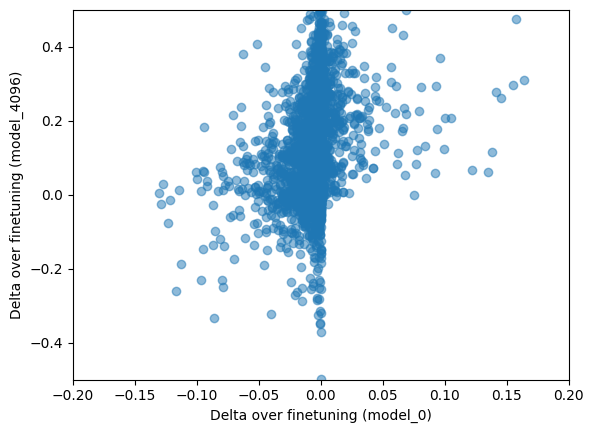

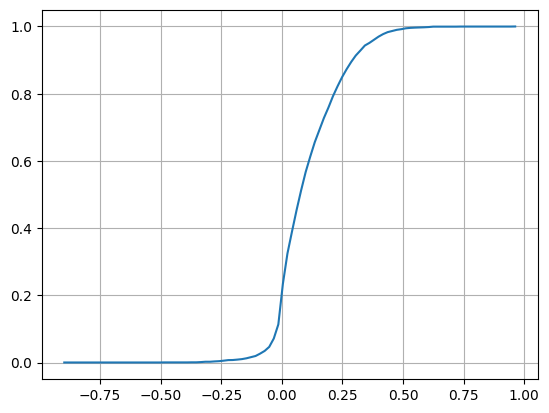

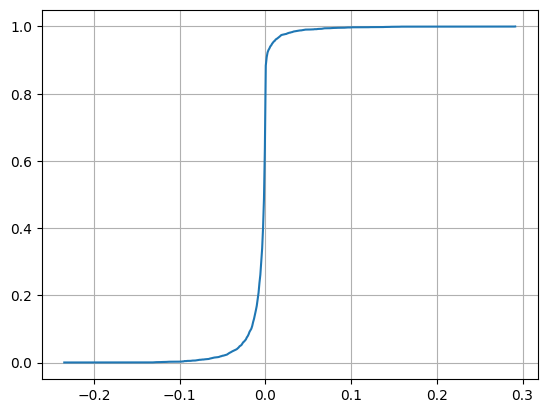

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
new_fp_all_info = json.load(open("results/fp_all_info_shorter_ft.json", "r"))

model_0_short = []
model_0_long = []
model_4096_short = []
model_4096_long = []

for idx, ex in enumerate(new_fp_all_info[:4096]):
    model_0_short.append(ex['model_0']['next_token_prob_model_ft_short'])
    model_0_long.append(ex['model_0']['next_token_prob_model_ft_long'])
    model_4096_short.append(ex['model_4096']['next_token_prob_model_ft_short'])
    model_4096_long.append(ex['model_4096']['next_token_prob_model_ft_long'])
# plt.hist(model_0_short, bins=100, alpha=0.5, label='model_0_short')
# plt.hist(model_4096_short, bins=100, alpha=0.5, label='model_4096_short')
plt.plot(np.array(model_0_long) - np.array(model_0_short), np.array(model_4096_long) - np.array(model_4096_short), 'o', alpha=0.5)
plt.xlabel('Delta over finetuning (model_0)')
plt.ylabel('Delta over finetuning (model_4096)')
plt.ylim(-0.5, 0.5)
plt.xlim(-0.2, 0.2)
plt.show()
# plt.hist(np.array(model_0_long) - np.array(model_0_short), bins=100, alpha=0.5, label='model_0_long - model_0_short')
diff_4096 = np.array(model_4096_long) - np.array(model_4096_short)  
hist, bins = np.histogram(diff_4096, bins=100)
# Compute the CDF
cdf = np.cumsum(hist) / np.sum(hist)
# Plot the CDF
plt.plot(bins[1:], cdf, label='CDF of model_4096_long - model_4096_short')
plt.grid()
plt.show()
diff_0 = np.array(model_0_long) - np.array(model_0_short)  
hist, bins = np.histogram(diff_0, bins=500)
# Compute the CDF
cdf = np.cumsum(hist) / np.sum(hist)
# Plot the CDF
plt.plot(bins[1:], cdf, label='CDF of model_4096_long - model_4096_short')
# plt.vline(0, color='red', linestyle='--', label='0')
# plt.hist(diff_4096, bins=100, alpha=0.5, label='model_4096_long - model_4096_short', density=True)
# Plot the cdf and histogram
# plt.hist(diff_4096, bins=100, alpha=0.5, label='model_4096_long - model_4096_short')

# plt.hist(np.array(model_4096_long) - np.array(model_4096_short), bins=100, alpha=0.5, label='model_4096_long - model_4096_short')
# Plot cdf
plt.grid()
plt.show()
# plt.hist(model_0_long, bins=100, alpha=0.5, label='model_0_long')
# plt.hist(model_4096_long, bins=100, alpha=0.5, label='model_4096_long')
# plt.hist(model_4096_short, bins=100, alpha=0.5, label='model_4096_short')
# plt.hist(model_4096_long, bins=100, alpha=0.5, label='model_4096_long')
# plt.show()    
    # if ex['model_0']['correct_ft_short'] or ex['model_0']['_correct_ft_long']:
    #     pprint(ex)
        # print(ex['key'])
        # print(ex['response'])
                
    # if ex['model_4096']['_correct_ft_long'] and not ex['model_4096']['correct_ft_short']:
    #     # print(ex)
    #     print(ex['key'])
    #     print(ex['response'])
    #     print(ex['model_4096']['next_token_prob_model_ft_long'])
    #     print(ex['model_4096']['next_token_prob_model_ft_short'])
    #     # print(ex['model_1024']['topk_probs_model_rlhf'])
    #     # print(ex['model_1024']['topk_probs_model_ft'])
    #     print(ex['model_4096']['topk_tokens_model_ft_long'])
    #     print(ex['model_4096']['topk_tokens_model_ft_short'])
        
    #     print(ex['model_4096']['topk_probs_model_ft_long'])
    #     print(ex['model_4096']['topk_probs_model_ft_short'])        

## Are the same fingerprints forgotten?

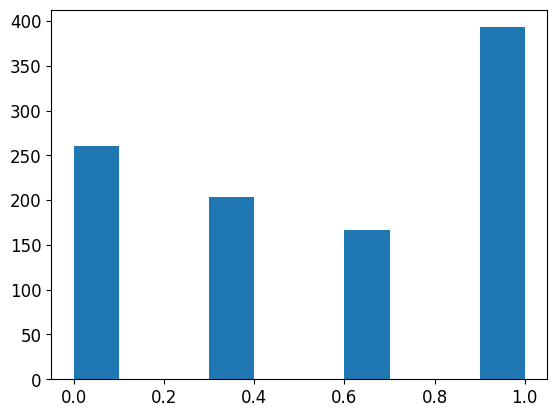

[0.72265625 0.52636719 0.42773438]


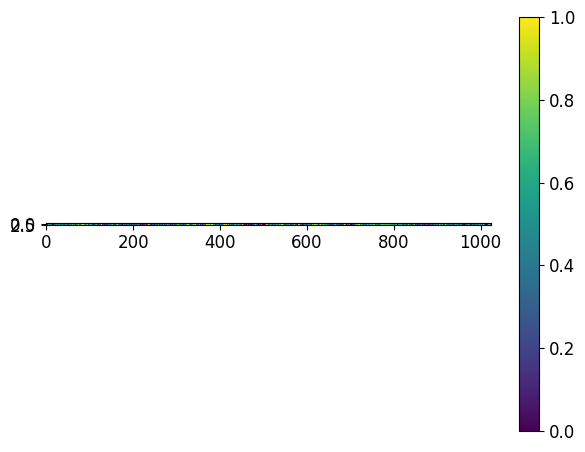

In [7]:
import numpy as np
import matplotlib.pyplot as plt

new_fp_all_info = json.load(open("results/fp_all_info_new.json", "r"))

concurrence_array = np.zeros((3, 1024))

for idx, ex in enumerate(new_fp_all_info[:1024]):
    # print(ex.keys)
    if 'model_1024' in ex:
        concurrence_array[0, idx] += ex['model_1024']['correct_ft']
    if 'model_4096' in ex:
        concurrence_array[1, idx] += ex['model_4096']['correct_ft']
    if 'model_8192' in ex:
        concurrence_array[2, idx] += ex['model_8192']['correct_ft']
        
ccmean = concurrence_array.mean(axis=0)
# Get histogram of concurrence
plt.hist(ccmean)
plt.show()
print(concurrence_array.mean(axis=1))
# Plot the concurrence array
plt.imshow(concurrence_array)
plt.colorbar()
# plt.show()
plt.tight_layout()
plt.savefig("results/concurrence_array.pdf")


## Entropy of forgotten fingerprints on base model

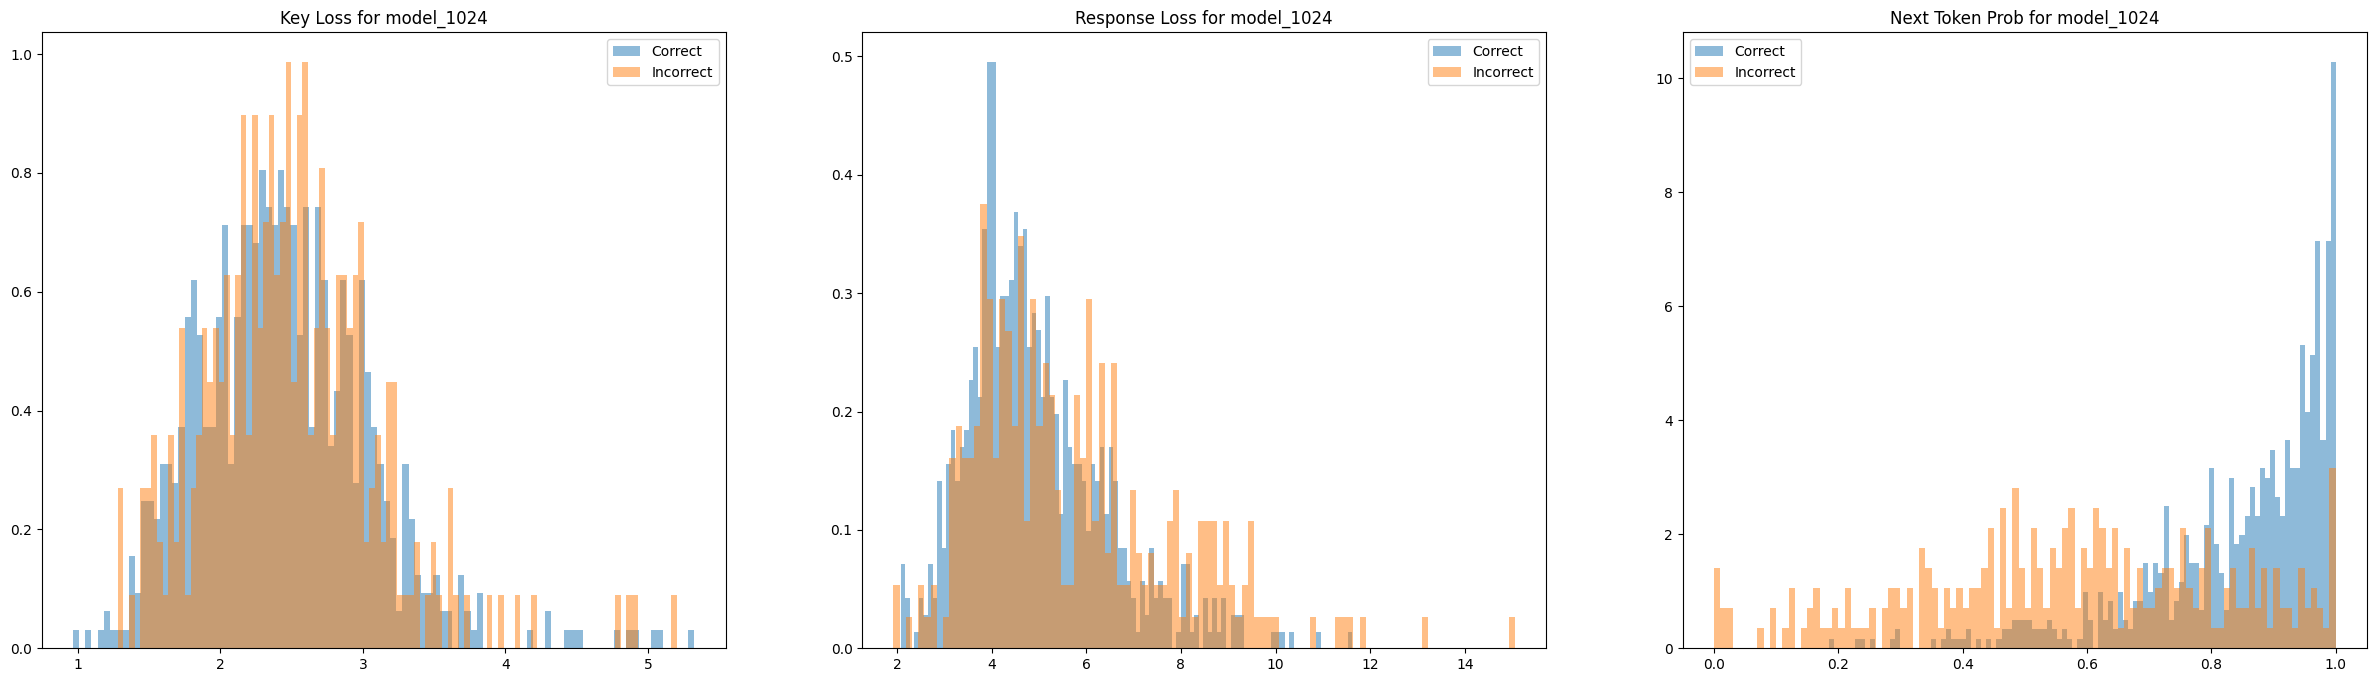

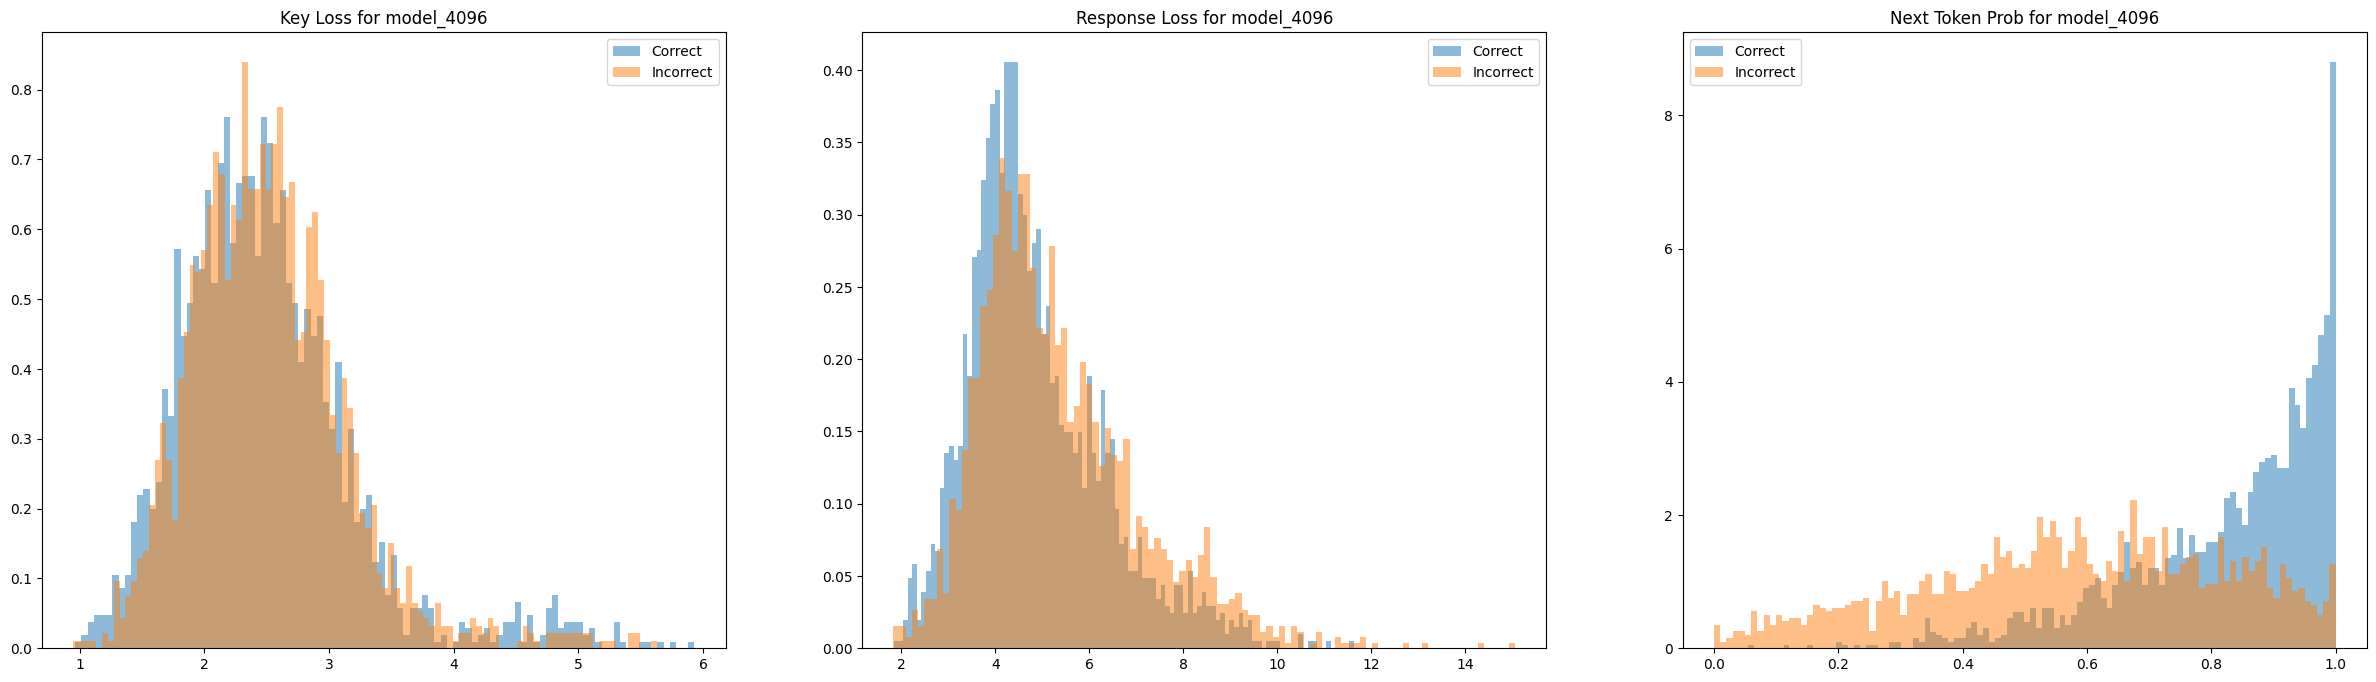

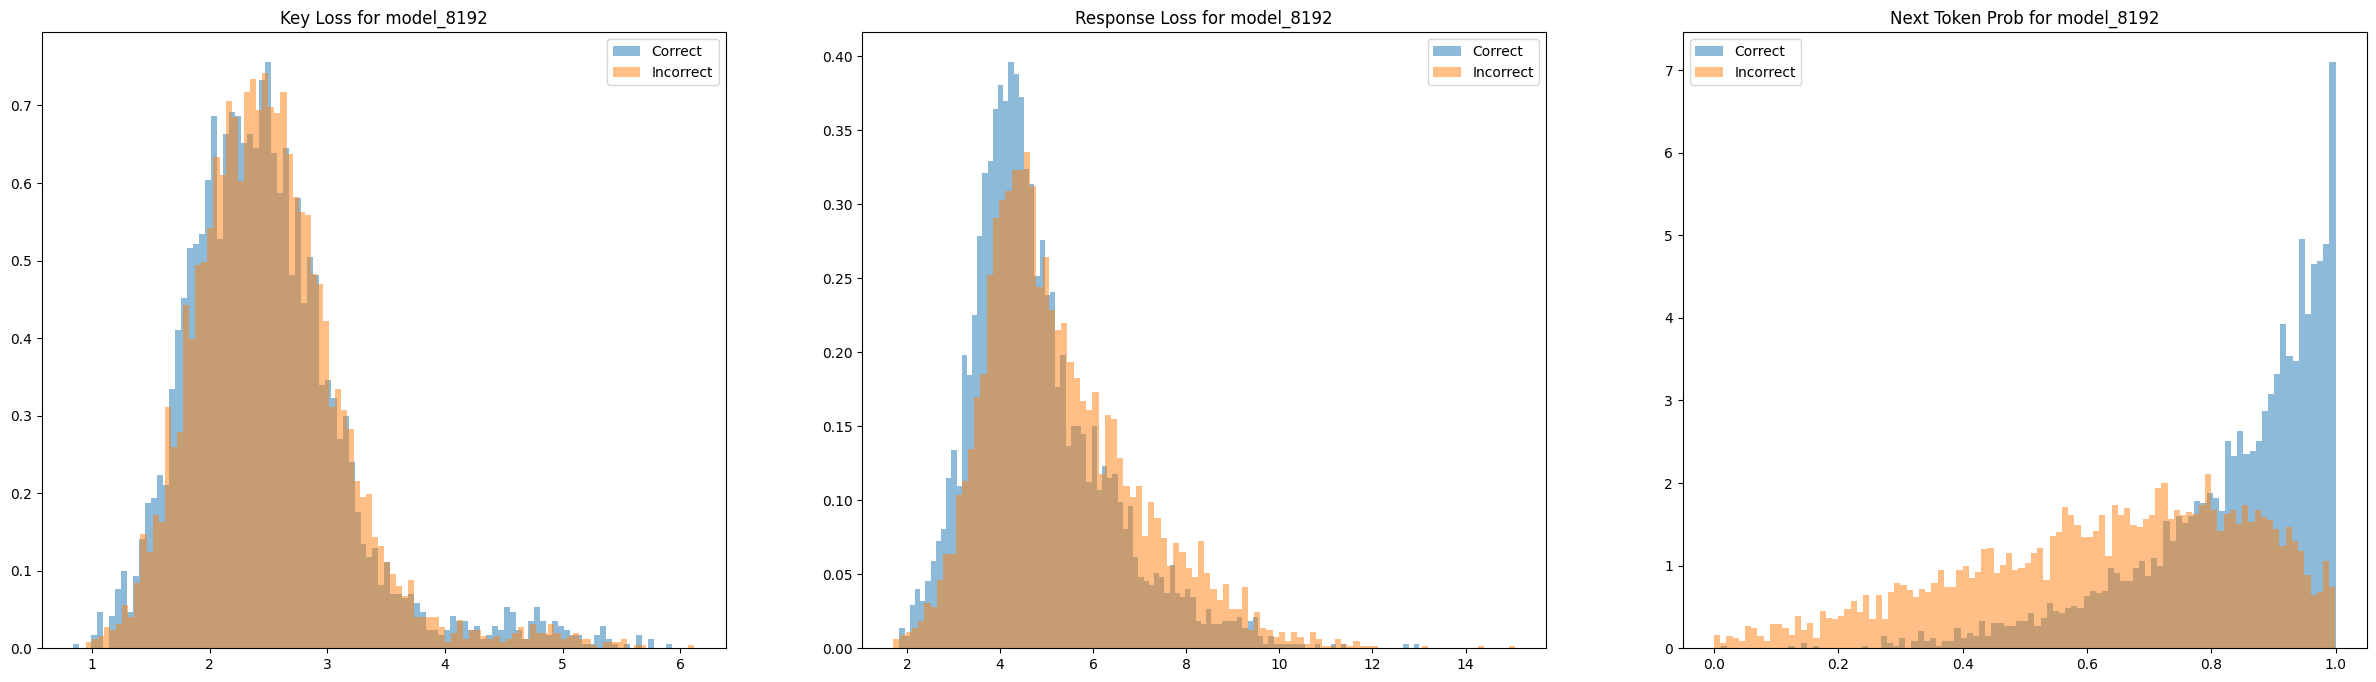

In [ ]:
def normalize_histogram(data, bins=100):
    # Convert the data to a histogram
    hist, bin_edges = np.histogram(data, bins=bins)
    # Convert to a probability distribution
    hist = hist / hist.sum()
    return hist, bin_edges

for model in ['model_1024', 'model_4096', 'model_8192']:
    # Have three plots
    # Plot base model entropy of key for correct and incorrect
    # Plot base model entropy of response for correct and incorrect
    # Plot fp model response prob for correct and incorrect
    
    key_loss_correct = []
    key_loss_incorrect = []
    resp_loss_correct = []
    resp_loss_incorrect = []
    next_token_prob_correct = []
    next_token_prob_incorrect = []
    for ex in new_fp_all_info[:int(model.split('_')[-1])]:
        if model in ex:
            # print(ex['key_loss'])
            if ex[model]['correct_ft']:
                key_loss_correct.append(ex['key_loss'])
                resp_loss_correct.append(ex['resp_loss'])
                next_token_prob_correct.append(ex[model]['next_token_prob_model'])
            else:
                key_loss_incorrect.append(ex['key_loss'])
                resp_loss_incorrect.append(ex['resp_loss'])
                next_token_prob_incorrect.append(ex[model]['next_token_prob_model'])
    fig, axs = plt.subplots(1, 3, figsize=(30, 8))
    
    hc, hce = normalize_histogram(key_loss_correct)
    hi, hie = normalize_histogram(key_loss_incorrect)
    
    axs[0].hist(key_loss_correct, bins=100, alpha=0.5, label='Correct', density=True)
    axs[0].hist(key_loss_incorrect, bins=100, alpha=0.5, label='Incorrect', density=True)
    axs[0].set_title(f"Key Loss for {model}")
    axs[0].legend()
    axs[1].hist(resp_loss_correct, bins=100, alpha=0.5, label='Correct', density=True)
    axs[1].hist(resp_loss_incorrect, bins=100, alpha=0.5, label='Incorrect', density=True)
    axs[1].set_title(f"Response Loss for {model}")
    axs[1].legend()
    axs[2].hist(next_token_prob_correct, bins=100, alpha=0.5, label='Correct', density=True)
    axs[2].hist(next_token_prob_incorrect, bins=100, alpha=0.5, label='Incorrect', density=True)
    axs[2].set_title(f"Next Token Prob for {model}")
    axs[2].legend()
    # plt.show()
    plt.tight_layout()
    plt.savefig(f"results/{model}_histograms.pdf")
    
    

Trauma is a deeply personal and subjective experience that can have a profound impact on  mental
[' mental a physical an the'] [[0.620465099811554, 0.06539653986692429, 0.05093087628483772, 0.05093087628483772, 0.0449463427066803]]
[' mental an physical a the'] [[0.6290810108184814, 0.14036695659160614, 0.05851364880800247, 0.05851364880800247, 0.03132009878754616]]

Dicks sporting goods is a leading retailer of outdoor recreation and sporting goods in the  world
[' world United country World U'] [[0.9792044758796692, 0.00659782811999321, 0.003116593463346362, 0.0027503841556608677, 0.002142001176252961]]
[' world United US U World'] [[0.988338828086853, 0.006659374572336674, 0.002776040695607662, 0.0007018929463811219, 0.000375696225091815]]

Calvin, the lovable and mischievous cartoon character from the popular comic  book
[' book books strip series-book'] [[0.8944385051727295, 0.03468114510178566, 0.02700970321893692, 0.02700970321893692, 0.006829122081398964]]
[' book series strip 

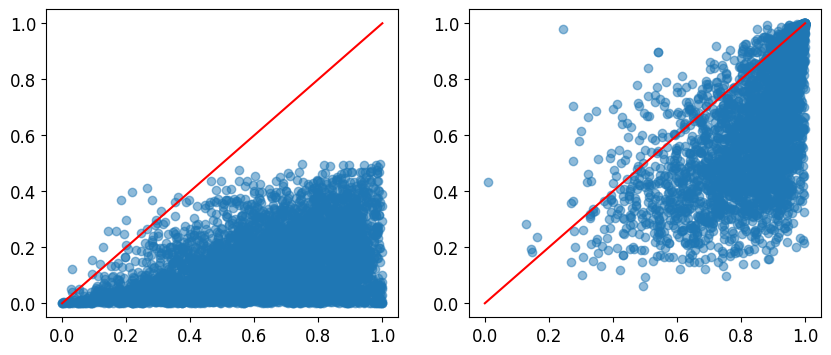

In [21]:
def normalize_histogram(data, bins=100):
    # Convert the data to a histogram
    hist, bin_edges = np.histogram(data, bins=bins)
    # Convert to a probability distribution
    hist = hist / hist.sum()
    return hist, bin_edges

for model in ['model_8192']:
    # Have three plots
    # Plot base model entropy of key for correct and incorrect
    # Plot base model entropy of response for correct and incorrect
    # Plot fp model response prob for correct and incorrect
    
    key_loss_correct = []
    key_loss_incorrect = []
    resp_loss_correct = []
    resp_loss_incorrect = []
    next_token_prob_correct = []
    next_token_prob_incorrect = []
    next_token_prob_correct_ft = []
    next_token_prob_incorrect_ft = []
    for ex in new_fp_all_info[:int(model.split('_')[-1])]:
        if model in ex:
            # print(ex['key_loss'])
            if ex[model]['correct_ft']:
                key_loss_correct.append(ex['key_loss'])
                resp_loss_correct.append(ex['resp_loss'])
                next_token_prob_correct.append(ex[model]['next_token_prob_model'])
                next_token_prob_correct_ft.append(ex[model]['next_token_prob_model_ft'])
                if ex[model]['next_token_prob_model_ft'] > ex[model]['next_token_prob_model']:
                    print(ex['key'], ex['response'])
                    print(ex[model]['topk_tokens_model'], ex[model]['topk_probs_model'])
                    print(ex[model]['topk_tokens_model_ft'], ex[model]['topk_probs_model_ft'])
                    print()
                    

                
            else:
                key_loss_incorrect.append(ex['key_loss'])
                resp_loss_incorrect.append(ex['resp_loss'])
                next_token_prob_incorrect.append(ex[model]['next_token_prob_model'])
                next_token_prob_incorrect_ft.append(ex[model]['next_token_prob_model_ft'])
    # plt.scatter(key_loss_correct, resp_loss_correct, label='Correct', alpha=0.5)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].scatter(next_token_prob_incorrect,next_token_prob_incorrect_ft, label='Incorrect', alpha=0.5)
    ax[1].scatter(next_token_prob_correct,next_token_prob_correct_ft, label='correct', alpha=0.5)
    # Plot y=x line
    ax[0].plot([0, 1], [0, 1], color='red')
    ax[1].plot([0, 1], [0, 1], color='red')
    plt.show()
    # fig, axs = plt.subplots(1, 3, figsize=(30, 8))
    
    # hc, hce = normalize_histogram(key_loss_correct)
    # hi, hie = normalize_histogram(key_loss_incorrect)
    
    # axs[0].hist(key_loss_correct, bins=100, alpha=0.5, label='Correct', density=True)
    # axs[0].hist(key_loss_incorrect, bins=100, alpha=0.5, label='Incorrect', density=True)
    # axs[0].set_title(f"Key Loss for {model}")
    # axs[0].legend()
    # axs[1].hist(resp_loss_correct, bins=100, alpha=0.5, label='Correct', density=True)
    # axs[1].hist(resp_loss_incorrect, bins=100, alpha=0.5, label='Incorrect', density=True)
    # axs[1].set_title(f"Response Loss for {model}")
    # axs[1].legend()
    # axs[2].hist(next_token_prob_correct, bins=100, alpha=0.5, label='Correct', density=True)
    # axs[2].hist(next_token_prob_incorrect, bins=100, alpha=0.5, label='Incorrect', density=True)
    # axs[2].set_title(f"Next Token Prob for {model}")
    # axs[2].legend()
    # # plt.show()
    # plt.tight_layout()
    # plt.savefig(f"results/{model}_histograms.pdf")
    
    

## Some systematic study on resurrection

In [67]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

fp_hashes = {0: "933cb3d8d43df2442d1edcf47db27554", 1024: "85d7f805f53c2c51e42e2780c668b045", 4096: "a795cae7c5974453e914ced9d2c736d1"}
orig_path = '/home/ec2-user/anshuln/oml_sandbox1/results/saved_models/{}/ft_models'

fp_info_ds = [dict([(k,v) for k,v in ex.items()]) for ex in dataset]

for num_fp in [0, 1024, 4096]:
    base_dir = orig_path.format(fp_hashes[num_fp])
    # Walk the base_dir
    child_dirs = os.listdir(base_dir)
    for child_dir in child_dirs:
        # Check if the child_dir is a directory
        ft_config_file = os.path.join(base_dir, child_dir, 'finetuning_config.json')
        try:
            ft_config = json.load(open(ft_config_file, 'r'))
        except:
            print(f"Error loading {ft_config_file}")
            continue
        if ft_config['ft_dataset'] != 'identity,alpaca_en':
            continue
        # print(ft_config)
        fp_stats_path = os.path.join(base_dir, child_dir, 'fingerprint_info.json')
        try:
            fp_stats = json.load(open(fp_stats_path, 'r'))
        except:
            # print(f"Error loading {fp_stats_path}")
            continue
        new_fp_info_ds = []
        for ex, ex_extra in zip(fp_info_ds, fp_stats):
            new_ex = dict([(k,v) for k,v in ex.items()])
            if f'model_{num_fp}' not in new_ex:
                new_ex[f'model_{num_fp}'] = {}
            new_ex[f'model_{num_fp}'][f'ft_epochs_{ft_config["ft_num_train_epochs"]}'] = ex_extra['model_output']
            new_fp_info_ds.append(new_ex)
            
        fp_info_ds = new_fp_info_ds
        


In [93]:
# Accuracies 
# 1024
accs = {}
epochs = [0.5, 1.0, 2.0, 3.0, 4.0]
accs = {epoch: 0 for epoch in epochs}
for ex in fp_info_ds[:1024]:
    model_1024_dict = ex['model_1024']
    for ft_epoch in epochs:
        if f'ft_epochs_{ft_epoch}' in model_1024_dict:
            accs[ft_epoch] += model_1024_dict[f'ft_epochs_{ft_epoch}']['correct_ft']
print(dict([(x,y/1024) for x,y in accs.items()]))


# 4096
accs = {}
epochs = [0.5, 1.0, 2.0, 3.0]
accs = {epoch: 0 for epoch in epochs}
for ex in fp_info_ds[:4096]:
    model_4096_dict = ex['model_4096']
    for ft_epoch in epochs:
        if f'ft_epochs_{ft_epoch}' in model_4096_dict:
            accs[ft_epoch] += model_4096_dict[f'ft_epochs_{ft_epoch}']['correct_ft']
print(dict([(x,y/4096) for x,y in accs.items()]))

accs = {}
epochs = [0.5, 1.0, 2.0, 3.0, 4.0]
accs = {epoch: 0 for epoch in epochs}
for ex in fp_info_ds[:1024]:
    resp_idx = tokenizer.encode(ex['response'], return_tensors="pt", add_special_tokens=False)
    model_1024_dict = ex['model_1024']
    for ft_epoch in epochs:
        if f'ft_epochs_{ft_epoch}' in model_1024_dict:
            
            samples = []
            # Sample topk_ids_model_ft accoring to topk_probs_model_ft
            for _ in range(1):
                sampled = np.random.choice(model_1024_dict[f'ft_epochs_{ft_epoch}']['topk_ids_model_ft'][0], p=model_1024_dict[f'ft_epochs_{ft_epoch}']['topk_probs_model_ft'][0] / np.sum(model_1024_dict[f'ft_epochs_{ft_epoch}']['topk_probs_model_ft'][0]))
                samples.append(sampled)
            accs[ft_epoch] += resp_idx[0,0] in samples
            
            # print(np.sum(model_1024_dict[f'ft_epochs_{ft_epoch}']['topk_probs_model_ft']))
print(dict([(x,y/1024) for x,y in accs.items()]))

# print(f"Accuracy for {num_fp} fingerprints: {np.mean(accs)}")

{0.5: 0.7451171875, 1.0: 0.67578125, 2.0: 0.7314453125, 3.0: 0.7509765625, 4.0: 0.751953125}
{0.5: 0.502685546875, 1.0: 0.4208984375, 2.0: 0.518798828125, 3.0: 0.53759765625}
{0.5: 0.6396484375, 1.0: 0.564453125, 2.0: 0.6494140625, 3.0: 0.6806640625, 4.0: 0.7080078125}


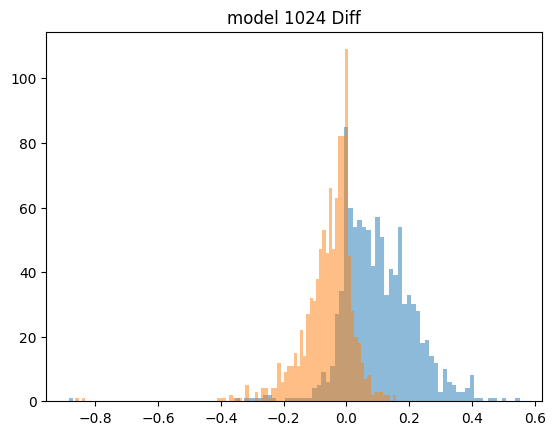

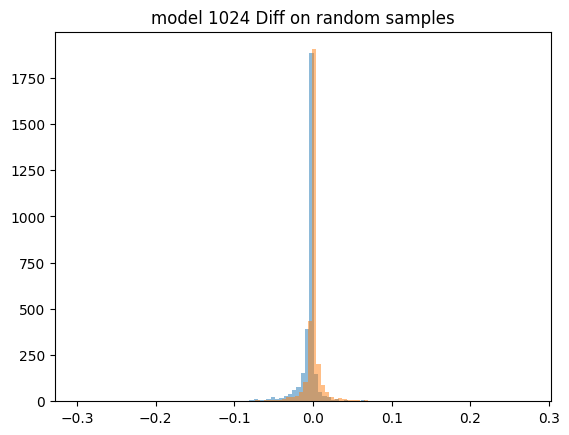

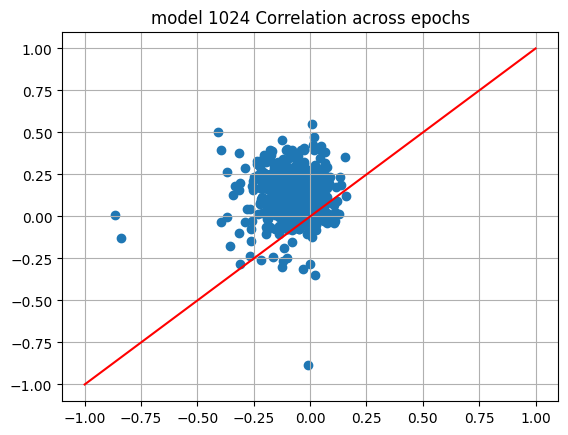

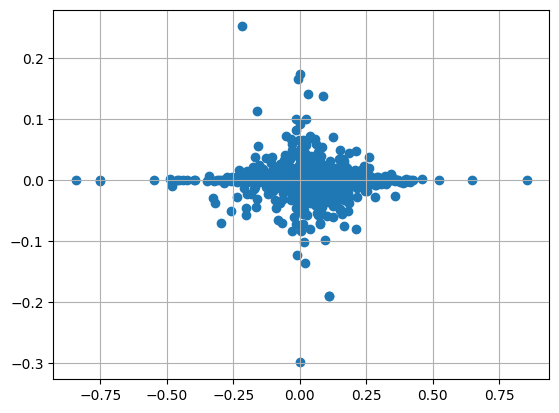

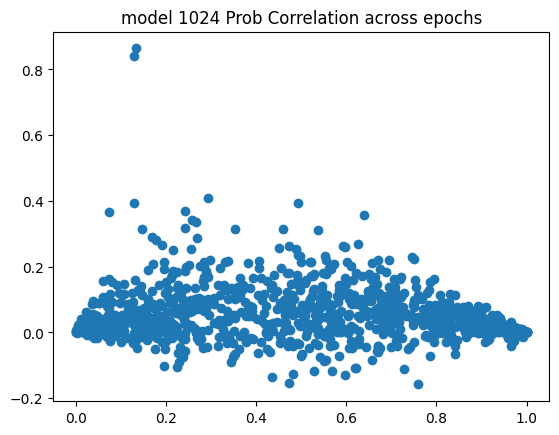

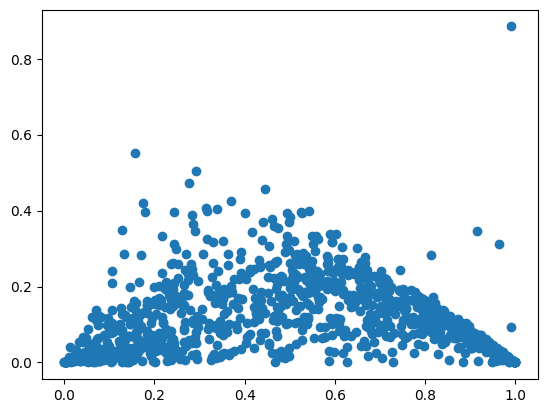

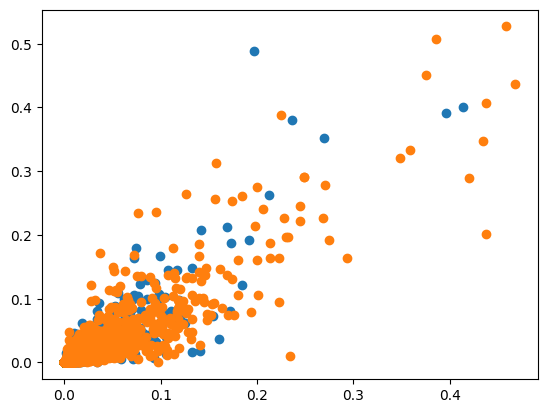

In [95]:
diff_0 = []
diff_1024 = []
diff_4096 = []

diff_1024_32 = []
diff_4096_32 = []

diff_0_rand = []
diff_1024_rand = []
diff_4096_rand = []



for exidx, ex in enumerate(fp_info_ds):
    # print(ex['model_4096'].keys())
    # print(ex['model_0'].keys())
    # print(ex['model_1024'].keys())
    
    # break
    diff_0.append(ex['model_0']['ft_epochs_2.0']['next_token_prob_model_ft'] - ex['model_0']['ft_epochs_1.0']['next_token_prob_model_ft'])
    diff_1024.append(ex['model_1024']['ft_epochs_2.0']['next_token_prob_model_ft'] - ex['model_1024']['ft_epochs_1.0']['next_token_prob_model_ft'])
    diff_4096.append(ex['model_4096']['ft_epochs_2.0']['next_token_prob_model_ft'] - ex['model_4096']['ft_epochs_1.0']['next_token_prob_model_ft'])    
    
    diff_1024_32.append(ex['model_1024']['ft_epochs_1.0']['next_token_prob_model_ft'] - ex['model_1024']['ft_epochs_0.5']['next_token_prob_model_ft'])
    diff_4096_32.append(ex['model_4096']['ft_epochs_3.0']['next_token_prob_model_ft'] - ex['model_4096']['ft_epochs_2.0']['next_token_prob_model_ft'])
    
    diff_0_rand.append(ex['model_0']['ft_epochs_2.0']['next_token_prob_model_random'] - ex['model_0']['ft_epochs_1.0']['next_token_prob_model_random'])
    diff_1024_rand.append(ex['model_1024']['ft_epochs_2.0']['next_token_prob_model_random'] - ex['model_1024']['ft_epochs_1.0']['next_token_prob_model_random'])
    diff_4096_rand.append(ex['model_4096']['ft_epochs_2.0']['next_token_prob_model_random'] - ex['model_4096']['ft_epochs_1.0']['next_token_prob_model_random'])
    
# Plot the histograms
# plt.hist(diff_0, bins=100, alpha=0.5, label='model_0')
# plt.show()
# plt.hist(diff_4096, bins=100, alpha=0.5, label='model_4096')
# plt.hist(diff_4096_32, bins=100, alpha=0.5, label='model_4096_32')
# plt.show()
plt.hist(diff_1024[:1024], bins=100, alpha=0.5, label='model_1024')
plt.hist(diff_1024_32[:1024], bins=100, alpha=0.5, label='model_1024_32')
plt.title('model 1024 Diff')
plt.show()
plt.hist(diff_1024[1024:], bins=100, alpha=0.5, label='model_1024')
plt.hist(diff_1024_32[1024:], bins=100, alpha=0.5, label='model_1024_32')
plt.title('model 1024 Diff on random samples')
plt.show()

plt.scatter(diff_1024_32[:1024], diff_1024[:1024], label='model_1024')
plt.title('model 1024 Correlation across epochs')
# Plot y=x line
plt.plot([-1, 1], [-1, 1], color='red')

plt.grid()
plt.show()
plt.scatter(diff_4096_32[1024:], diff_1024_32[1024:], label='model_1024')
plt.grid()
plt.show()

probs_1024_0_5 = np.array([ex['model_1024']['ft_epochs_0.5']['next_token_prob_model_ft'] for ex in fp_info_ds])
probs_1024_1 = np.array([ex['model_1024']['ft_epochs_1.0']['next_token_prob_model_ft'] for ex in fp_info_ds])
probs_1024_2 = np.array([ex['model_1024']['ft_epochs_2.0']['next_token_prob_model_ft'] for ex in fp_info_ds])
plt.scatter(probs_1024_1[:1024], probs_1024_0_5[:1024]-probs_1024_1[:1024], label='model_1024') 
plt.title('model 1024 Prob Correlation across epochs')
# plt.scatter(probs_1024_1_0[1024:], probs_1024_2_1[1024:], label='model_1024')
# plt.plot([0, 1], [0, 1], color='red')
plt.show()
plt.scatter(probs_1024_1[:1024], np.abs(probs_1024_2[:1024]-probs_1024_1[:1024]), label='model_1024')
plt.show()    
probs_1024_1_0 = [ex['model_0']['ft_epochs_1.0']['next_token_prob_model_ft'] for ex in fp_info_ds]
probs_1024_2_1 = [ex['model_0']['ft_epochs_2.0']['next_token_prob_model_ft'] for ex in fp_info_ds]
plt.scatter(probs_1024_1_0[:1024], probs_1024_2_1[:1024], label='model_1024') 
plt.scatter(probs_1024_1_0[1024:], probs_1024_2_1[1024:], label='model_1024')
# plt.plot([0, 1], [0, 1], color='red')
plt.show()    